# Multi-fidelity Nested VeBRNN training
This notebook guidance on how to train `MF-Nested-VeBRNN` of the `MF-VeBRNN` repo.

In [1]:

import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from MFVeBRNN.dataset.load_dataset import  MultiFidelityDataset
from MFVeBRNN.method.mf_nest_vebrnn_trainer import MFNestVeBRNNTrainer
from VeBNN.networks import MeanNet, GammaVarNet
from torch import nn
import warnings
warnings.filterwarnings("ignore")

## Load dataset

In [2]:
dataset = MultiFidelityDataset(lf_train_data_path = "lf_dns_sve_0d1.pickle",
                         hf_train_data_path= "hf_dns_rve_0d1.pickle",
                         id_ground_truth=True,
                         id_hf_test_data_path="hf_dns_rve_0d1_gt.pickle",
                         id_lf_ground_truth_data_path="lf_dns_sve_0d1_gt.pickle",
                         ood_ground_truth=True,
                         ood_hf_test_data_path="hf_dns_rve_0d125_gt.pickle",
                         ood_lf_ground_truth_data_path="lf_dns_sve_0d125_gt.pickle",)
dataset.get_hf_train_val_split(num_hf_train=100, num_hf_val=10, seed=0)
dataset.get_lf_train_val_split(num_lf_train=100, num_lf_val=0, seed=0)

The dataset is loaded successfully.
Number of low-fidelity training samples: 2981
Number of high-fidelity training samples: 1291
Number of in-distribution test samples: 99
Number of out-of-distribution test samples: 99


## Define a simple GRU network 
Since the history dependent constitutive law is has recurrent data structure, we need a recurrent neural network for this task. 

In [3]:
class SimpleGRU(nn.Module):
    def __init__(self,
                 input_size: int,
                 hidden_size: int,
                 num_layers: int,
                 output_size: int,
                 bias: bool = True):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          bias=bias,
                          batch_first=True,
                        )
        self.h2y = nn.Linear(hidden_size, output_size)

    def forward(self, x, hx=None):
        out, _ = self.gru(x, hx)      # (B, T, hidden_size)
        y = self.h2y(out)             # (B, T, output_size)
        return y

In [4]:
# define the mean and variance networks
mean_network_ = SimpleGRU(input_size=6,
                         hidden_size=64,
                         num_layers=2,
                         output_size=3)
mean_network = MeanNet(net=mean_network_,
                       prior_mu=0.0,
                       prior_sigma=1.0)
# define the variance network
var_network_ = SimpleGRU(input_size=6,
                        hidden_size=4,
                        num_layers=1,
                        output_size=6)
var_network = GammaVarNet(net=var_network_,
                            prior_mu=0.0,
                            prior_sigma=1.0)

## Training setup

In [5]:

# load the pre-trained low-fidelity model
lf_pre_trained_model = torch.load("single_fidelity_rnn_model.pth", weights_only=False)

mf_model = MFNestVeBRNNTrainer(
    mean_net=mean_network,
    var_net=var_network,
    pre_trained_lf_model=lf_pre_trained_model,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    nest_option="output",
    job_id=1
)


In [6]:


# ====== configs (kept small so test is fast) ======
init_config = {
    "loss_name": "MSE",
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-6,
    "num_epochs": 1000,      # warm-up epochs
    "batch_size": 200,
    "verbose": False,
    "print_iter": 50,
    "split_ratio": 0.8,
}

var_config = {
    "optimizer_name": "Adam",
    "lr": 1e-3,
    "num_epochs": 1000,
    "batch_size": 200,
    "verbose": True,
    "print_iter": 50,
    "early_stopping": False,
    "early_stopping_iter": 100,
    "early_stopping_tol": 1e-4,
}

sampler_config = {
    "sampler": "pSGLD",   # must match your VeBNN.samplers names
    "lr": 1e-3,
    "gamma": 0.9999,
    "num_epochs": 2000,    # SGMCMC epochs
    "mix_epochs": 10,     # thinning interval
    "burn_in_epochs": 500,
    "batch_size": 200,
    "verbose": False,
    "print_iter": 100,
}




In [7]:
# ====== run cooperative training ======
# For a quick test, iteration=2 is enough to see if everything works.
mf_model.cooperative_train(
    x_train=dataset.hx_train,
    y_train=dataset.hy_train,
    iteration=1,
    init_config=init_config,
    var_config=var_config,
    sampler_config=sampler_config,
    delete_model_raw_data=True,  # delete temporary folder after training
)


Step 2: Train for the variance network, iteration 1
Epoch/Total: 0/1000, Gamma NLL: -4.951e+04, neg log prior: 1.678e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 50/1000, Gamma NLL: -6.808e+04, neg log prior: 1.679e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 100/1000, Gamma NLL: -8.429e+04, neg log prior: 1.685e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 150/1000, Gamma NLL: -1.007e+05, neg log prior: 1.694e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 200/1000, Gamma NLL: -1.141e+05, neg log prior: 1.702e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 250/1000, Gamma NLL: -1.214e+05, neg log prior: 1.706e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 300/1000, Gamma NLL: -1.252e+05, neg log prior: 1.709e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 350/1000, Gamma NLL: -1.275e+05, neg log prior: 1.712e+02, log marginal likelihood: 0.000e+00
Epoch/Total: 400/1000, Gamma NLL: -1.290e+05, neg log prior: 1.714e+02, log marginal likelihood

## Get MF-Nested-VeBRNN's prediction

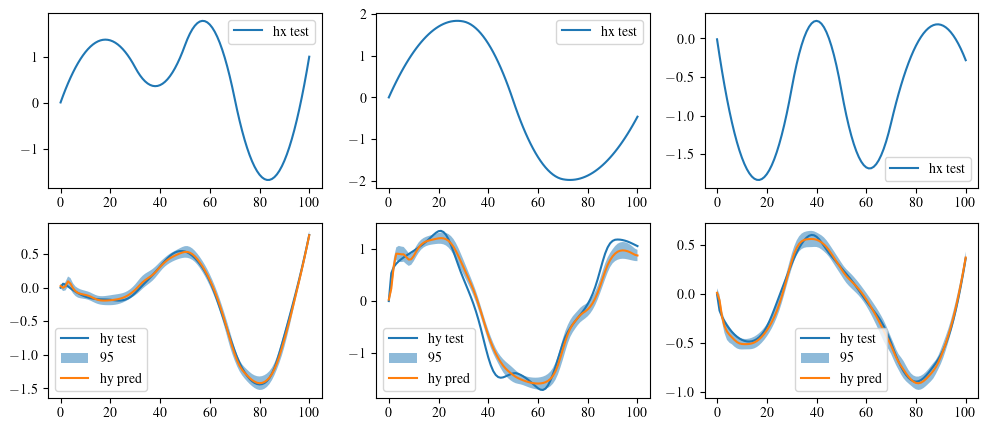

In [9]:
index = 2
hy_pred, hf_var = mf_model.hf_bayes_predict(dataset.hx_id_gt_scaled)
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
for i in range(3):
    ax[0, i].plot(dataset.hx_id_gt_scaled[index, :, i], label='hx test')
    ax[0, i].legend()
    ax[1, i].plot(dataset.hy_id_gt_scaled[index, :, i], label='hy test')
    ax[1, i].fill_between(
        range(len(hy_pred[index, :, i].cpu())),
        hy_pred[index, :, i].cpu() - 1.96 * torch.sqrt(hf_var[index, :, i].cpu()),
        hy_pred[index, :, i].cpu() + 1.96 * torch.sqrt(hf_var[index, :, i].cpu()),
        alpha=0.5,
        label='95% CI'
    )
    ax[1, i].plot(hy_pred[index, :, i].cpu(), label='hy pred')
    ax[1, i].legend()
# save the figure

plt.show()


## Have fun! 